In [ ]:
import pandas as pd
import numpy as np
import gower
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats.contingency import crosstab

import load.load_dataset as ds

from umap import UMAP
from sklearn.cluster import HDBSCAN

import seaborn as sns
import matplotlib.pyplot as plt

import os
import joblib

import warnings
warnings.filterwarnings('ignore')
np.random.seed(0)

In [2]:
model_list = ['model1r','model2r', 'model3r']

param_dict = joblib.load(os.path.join(os.getcwd(), "parameters.joblib"))

for dataset in param_dict:
    print(f"########## {dataset} ##########")
    for param in param_dict[dataset]:
        print(f"{param}: {param_dict[dataset][param]}")
    print("\n")

########## adult ##########
n_clust: 1000
ensemble_medoid_k: 9
ensemble_medoid_th: 0.8
ensemble_random_k: 5
ensemble_random_th: 0.7
mean_medoid_k: 9
mean_medoid_th: 0.8
mean_random_k: 5
mean_random_th: 0.7


########## bank ##########
n_clust: 1000
ensemble_medoid_k: 7
ensemble_medoid_th: 0.8
mean_random_k: 9
mean_random_th: 0.75
ensemble_random_k: 7
ensemble_random_th: 0.75
mean_medoid_k: 11
mean_medoid_th: 0.8


########## beans ##########
n_clust: 225
ensemble_medoid_k: 9
ensemble_medoid_th: 0.85
mean_medoid_k: 9
mean_medoid_th: 0.9
ensemble_random_k: 5
ensemble_random_th: 0.75
mean_random_k: 7
mean_random_th: 0.8


########## cancer ##########
n_clust: 10
ensemble_medoid_k: 11
ensemble_medoid_th: 0.85
mean_medoid_k: 9
mean_medoid_th: 0.9
ensemble_random_k: 5
ensemble_random_th: 0.55
mean_random_k: 7
mean_random_th: 0.65


########## heloc ##########
n_clust: 130
ensemble_medoid_k: 15
ensemble_medoid_th: 0.8
mean_medoid_k: 13
mean_medoid_th: 0.8
ensemble_random_k: 11
ensemble_random

# Per dataset Hyperpar tuning
per dataset analysis of k_r and r_threshold

In [4]:
dataset_name = "bank"

neigh = "medoid" # medoid random
agg = "ensemble" # ensemble mean

methods_labels = ["IG", "DL", "LRP", agg]

folder = os.path.join(os.getcwd(), f"results_{neigh}")

In [5]:
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal,discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()

print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(36168, 14) (8043, 14) (1000, 14)


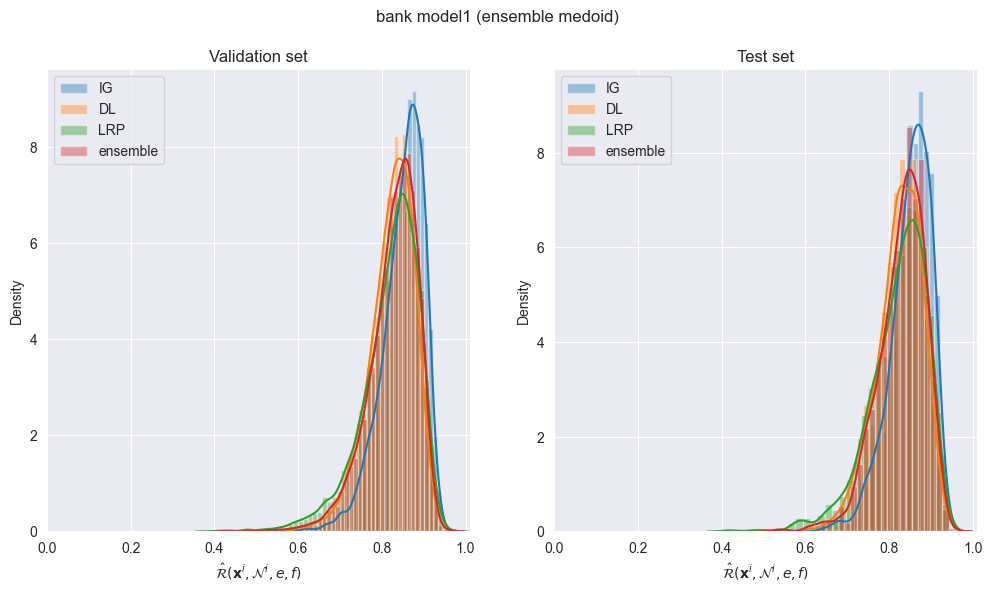

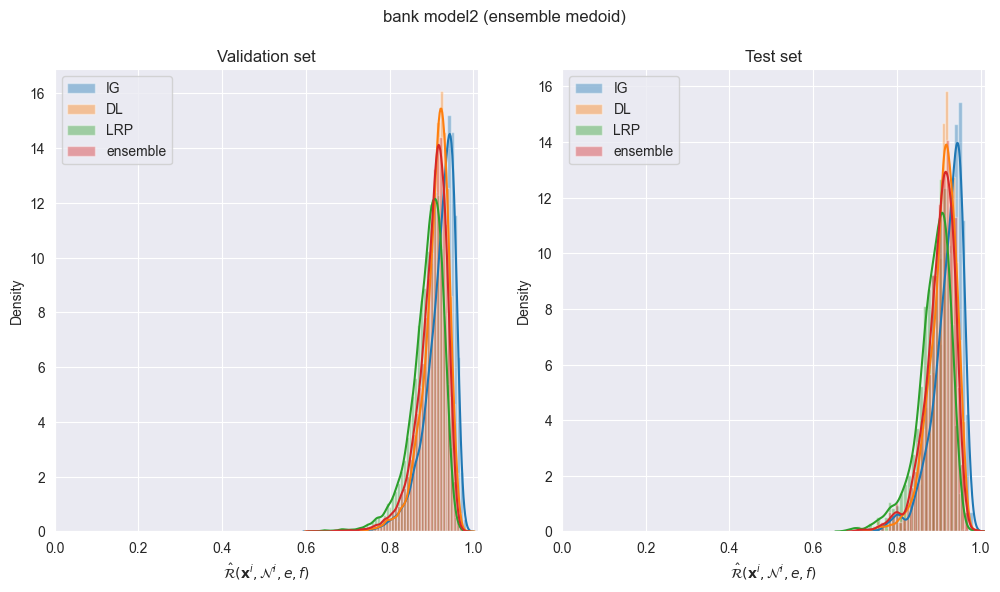

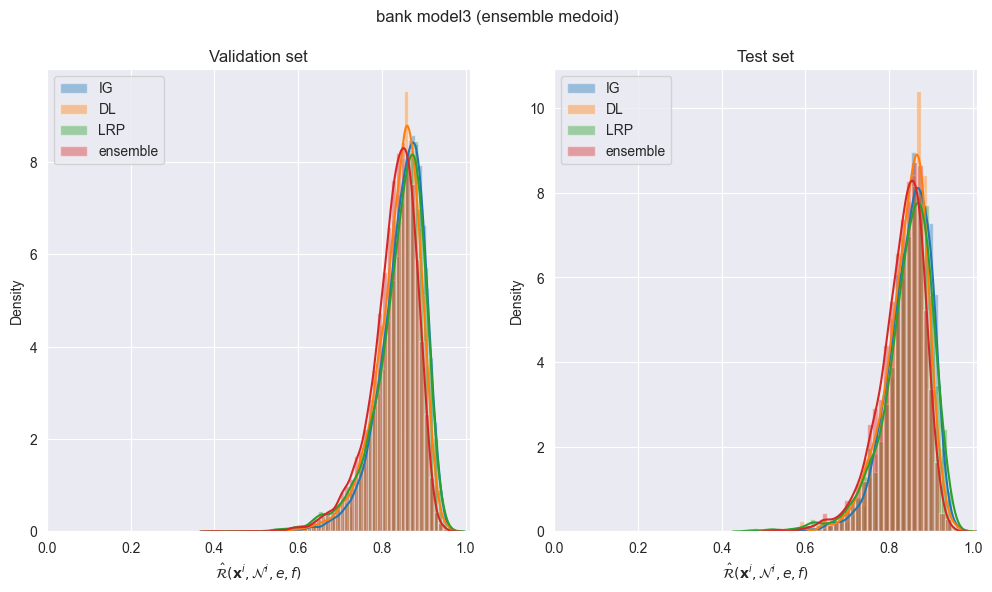

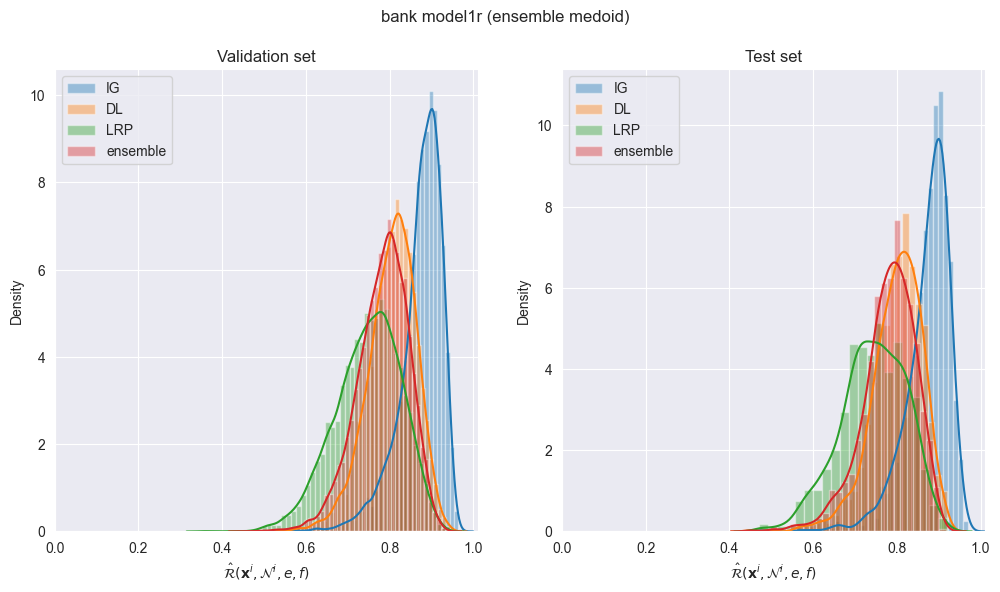

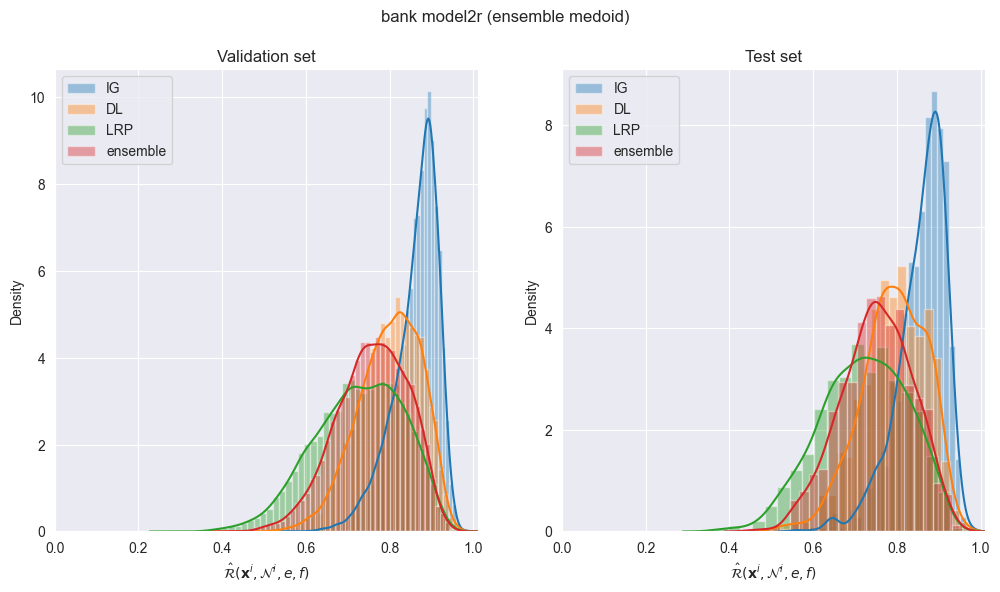

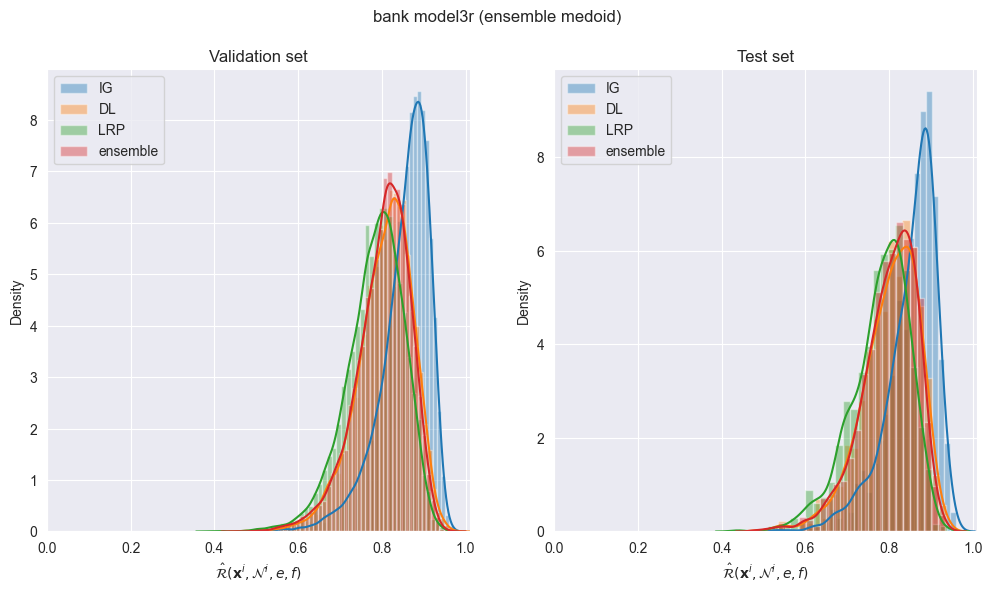

In [6]:
for model_name in model_list:
    folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")

    rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))
    rho_test = np.load(os.path.join(folder_, "test", f"robustness_{agg}_{neigh}.npy"))

    fig, ax = plt.subplots(1,2, figsize=(12,6))
    for i in range(len(methods_labels)):
        sns.distplot(rho_valid[:,i], ax = ax[0], label=methods_labels[i])
        sns.distplot(rho_test[:,i], ax= ax[1], label=methods_labels[i])

    ax[0].set_title("Validation set")
    ax[1].set_title("Test set")
    ax[0].legend()
    ax[1].legend()
    ax[0].set_xlim(0, 1.01)
    ax[1].set_xlim(0,1.01)
    ax[0].set_xlabel("$\hat{\mathcal{R}}(\mathbf{x}^i, \mathcal{N}^{i}, e, f)$")
    ax[1].set_xlabel("$\hat{\mathcal{R}}(\mathbf{x}^i, \mathcal{N}^{i}, e, f)$")
    plt.suptitle(f"{dataset_name} {model_name} ({agg} {neigh})")
    plt.show()

# confirm that the validation and test sets have comparable robustness distributions (prop.5)

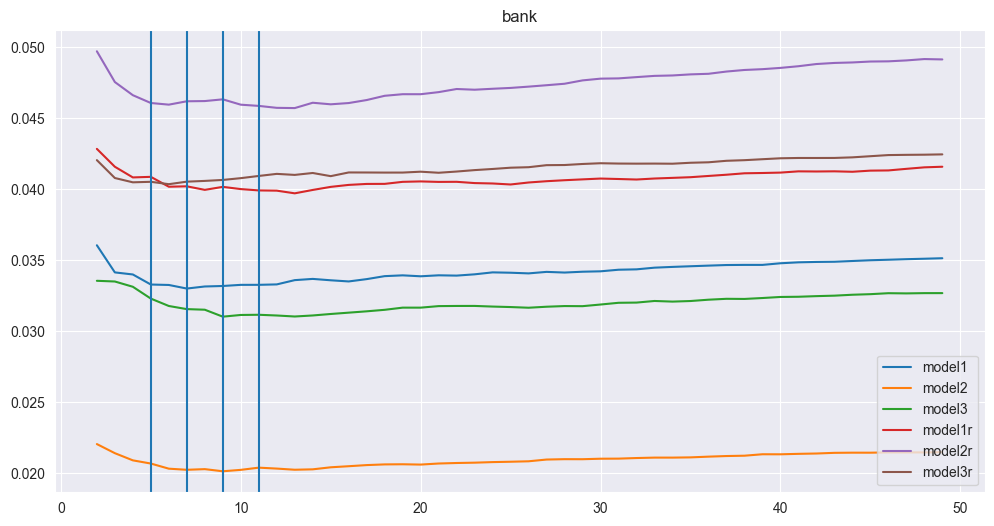

In [7]:
plt.figure(figsize=(12,6))
for model_name in [m for m in model_list]: # if m != 'model1r' and m != 'model2r' and m != 'model3r'
    folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")

    rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))
    rho_test = np.load(os.path.join(folder_, "test", f"robustness_{agg}_{neigh}.npy"))

    rho_valid = np.nan_to_num(rho_valid)

    tmp = []
    for k in range(2,50):
        regr = KNeighborsRegressor(n_neighbors=k).fit(X_val_or, rho_valid[:,3])
        rob_ = regr.predict(X_test_or)

        tmp.append(np.mean(np.abs(rho_test[:,3]-rob_)))
    
    plt.plot(range(2,50), tmp, label = model_name)

plt.axvline(x=5)
plt.axvline(x=7)
plt.axvline(x=9)
plt.axvline(x=11)
plt.title(dataset_name)
plt.legend()
plt.show()

In [9]:
k_r = 7
param_dict[dataset_name][f"{agg}_{neigh}_k"] = k_r

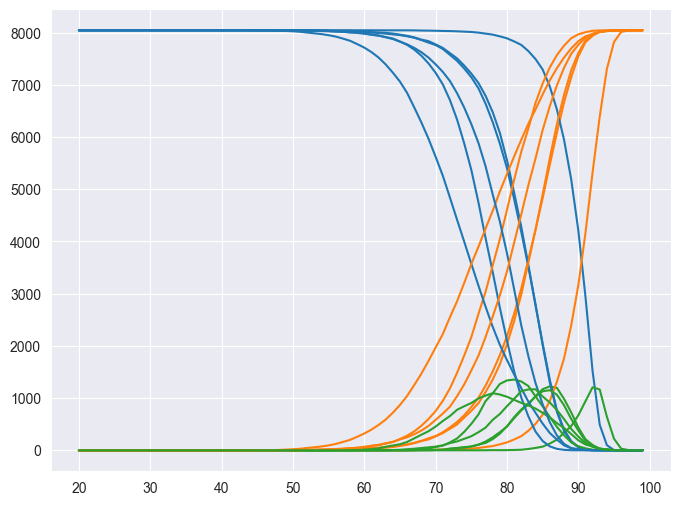

In [10]:
plt.figure(figsize=(8,6))
for model_name in [m for m in model_list]: # if m != 'model1' and m != 'model2' and m != 'model3'
    folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")

    rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))
    rho_valid = np.nan_to_num(rho_valid)
    rob_= rho_valid[:,3]

    regr = KNeighborsRegressor(n_neighbors=k_r).fit(X_val_or, rob_)
    rob_hat= regr.predict(X_val_or)

    non_robust = []
    robust = []
    other_=[]

    for th in range(20, 100):
        th = th/100
        
        robust.append(len(set.intersection(*map(set, [np.where(rob_ >= th)[0], np.where(rob_hat >= th)[0]]))))
        other_.append(len(set.intersection(*map(set, [np.where(rob_ >= th)[0], np.where(rob_hat < th)[0]]))))
        non_robust.append(len(np.where(rob_<th)[0]))

    plt.plot(range(20, 100), robust,  c = 'tab:blue')
    plt.plot(range(20, 100), non_robust,  c = 'tab:orange')
    plt.plot(range(20, 100), other_,  c ='tab:green')
plt.show()

In [11]:
th = 0.8
param_dict[dataset_name][f"{agg}_{neigh}_th"] = th

#joblib.dump(param_dict, os.path.join(os.getcwd(), "parameters.joblib"))

In [12]:
for dataset in param_dict:
    print(f"########## {dataset} ##########")
    for param in param_dict[dataset]:
        print(f"{param}: {param_dict[dataset][param]}")
    print("\n")

########## adult ##########
n_clust: 1000
ensemble_medoid_k: 9
ensemble_medoid_th: 0.8
ensemble_random_k: 5
ensemble_random_th: 0.7
mean_medoid_k: 9
mean_medoid_th: 0.8
mean_random_k: 5
mean_random_th: 0.7


########## bank ##########
n_clust: 1000
ensemble_medoid_k: 7
ensemble_medoid_th: 0.8
mean_random_k: 9
mean_random_th: 0.75
ensemble_random_k: 7
ensemble_random_th: 0.75
mean_medoid_k: 11
mean_medoid_th: 0.8


########## beans ##########
n_clust: 225
ensemble_medoid_k: 9
ensemble_medoid_th: 0.85
mean_medoid_k: 9
mean_medoid_th: 0.9
ensemble_random_k: 5
ensemble_random_th: 0.75
mean_random_k: 7
mean_random_th: 0.8


########## cancer ##########
n_clust: 10
ensemble_medoid_k: 11
ensemble_medoid_th: 0.85
mean_medoid_k: 9
mean_medoid_th: 0.9
ensemble_random_k: 5
ensemble_random_th: 0.55
mean_random_k: 7
mean_random_th: 0.65


########## heloc ##########
n_clust: 130
ensemble_medoid_k: 15
ensemble_medoid_th: 0.8
mean_medoid_k: 13
mean_medoid_th: 0.8
ensemble_random_k: 11
ensemble_random

# Per Model Check correctness of Hyperpar

Check for correctness of chosen k and th for each model

In [13]:
model_name = 'model3r'

k_r = param_dict[dataset_name][f"{agg}_{neigh}_k"]
th = param_dict[dataset_name][f"{agg}_{neigh}_th"]

print(model_name, dataset_name)

folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")
rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))
rho_test = np.load(os.path.join(folder_, "test", f"robustness_{agg}_{neigh}.npy"))
rho_valid = np.nan_to_num(rho_valid)
regr = KNeighborsRegressor(n_neighbors=k_r).fit(X_val_or, rho_valid[:,3])
rob_hat = regr.predict(X_test_or) # HERE we predict the robustness of the test set, via the knnregressor previously trained on the validation set
rob_= rho_test[:,3]

list_regressor = rob_hat >= th
list_real = rob_ >= th

overall = np.array(list_regressor).astype(int) + np.array(list_real).astype(int)
total = len(overall)
robust = len(np.where(overall==2)[0])
non_robust = len(np.where(list_real == 0)[0])
maybe = total - robust - non_robust

print("Robust", robust, "\nMaybe", maybe, "\nNon Robust", non_robust,"\nTotal", total)

# I want small maybe and robust >> 0

model3r bank
Robust 439 
Maybe 119 
Non Robust 442 
Total 1000


In [14]:
#joblib.dump(param_dict, os.path.join(os.getcwd(), "parameters.joblib"))

 check for propriety 2: dataset points that are close in the feature space, have similar robustness score

In [15]:
umap = UMAP(n_components=2, random_state=0, n_jobs=1)
X_new = umap.fit_transform(X_val_or)

hdbscan = HDBSCAN(min_cluster_size=100)
hdbscan.fit(X_new)
hdbs_labels = hdbscan.labels_
print(np.unique(hdbs_labels))

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23]


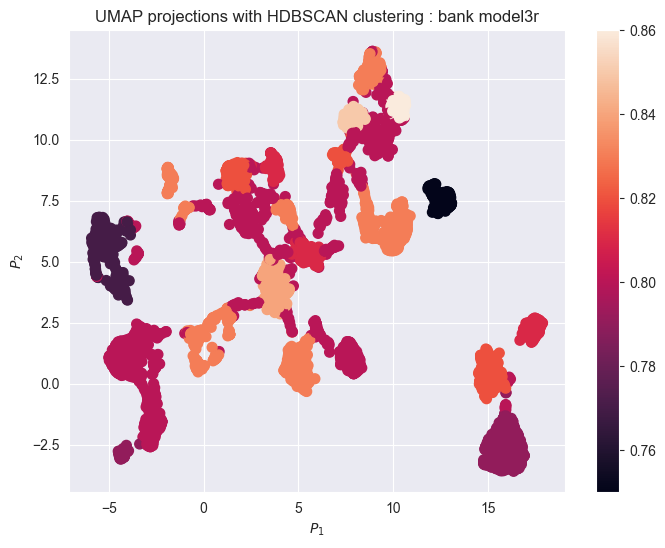

In [16]:
folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")
rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))

cols = []
for cl_idx in np.unique(hdbs_labels):
    rho_tmp = rho_valid[hdbs_labels==cl_idx]
    cols.append(np.round(np.nanmean(rho_tmp), 2))

cols = np.array(cols)
colors = cols[hdbs_labels]

plt.figure(figsize=(8,6))

plt.scatter(X_new[:,0], X_new[:,1], c=colors, s=50)
plt.title(f"UMAP projections with HDBSCAN clustering : {dataset_name} {model_name}")
plt.xlabel("$P_1$")
plt.ylabel("$P_2$")
plt.colorbar()
plt.show()

# EXECUTION
Using parameters in parameters.joblib fit the correct final krr regressor and produce the excel needed to compute the final ROC-AUC results

In [3]:
for neigh in ["medoid", "random"]:
    folder = os.path.join(os.getcwd(), f"results_{neigh}")
    for agg in  ["ensemble", "mean"]:
        final = []
        for dataset_name in param_dict.keys():

            dataset = ds.Dataset(dataset_name)
            X_val_or, X_val, y_val = dataset.validation()
            X_test_or, X_test, y_test = dataset.test()

            dim = X_test_or.shape[0]
            k_r = param_dict[dataset_name][f"{agg}_{neigh}_k"]

            gt = np.argmax(y_test.detach().numpy(), axis=1)
            model_pred = []
            for model_name in model_list:
                model = dataset.load_model(model_name)
                model_pred.append(np.argmax(model(X_test).detach().numpy(), axis=1))

            model_pred=np.array(model_pred)

            concordant_mask = np.all(model_pred == model_pred[0], axis=0)
            models3 = concordant_mask.astype(int)

            for model_name in model_list:
                folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")

                rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))
                rho_test = np.load(os.path.join(folder_, "test", f"robustness_{agg}_{neigh}.npy"))

                rho_valid = np.nan_to_num(rho_valid)

                regr = KNeighborsRegressor(n_neighbors=k_r).fit(X_val_or, rho_valid[:,3])
                rob_hat = regr.predict(X_test_or)
                rob_= rho_test[:,3]

                for th in np.arange(0,1, 0.01):
                    list_regressor = rob_hat >= th
                    list_real = rob_ >= th

                    overall = np.array(list_regressor).astype(int) + np.array(list_real).astype(int)
                    ROBUST = np.where(overall==2)[0]
                    NONROBUST = np.where(list_real == 0)[0]

                    total = len(overall)
                    robust = len(ROBUST)
                    non_robust = len(NONROBUST)
                    maybe = total - robust - non_robust

                    th_ = rob_ >= th

                    contingency = crosstab(models3, th_, levels=([1,0], [True, False]))

                    robust_cross = contingency.count[:,0]
                    non_robust_cross = contingency.count[:,1]

                    final.append([dataset_name, model_name, th, robust, maybe, non_robust, total, robust_cross[0], robust_cross[1], np.sum(th_), non_robust_cross[0], non_robust_cross[1], dim-np.sum(th_)])

        df = pd.DataFrame(final)
        df.columns = ["dataset", "model", "threshold", "robust", "maybe", "non robust", "len", "robust concordant", "robust discordant", "tot robust", "non robust concordant", "non robust discordant",  "tot non robust"]
        df.to_excel(os.path.join(os.getcwd(), "results_roc_auc", f"{agg}_{neigh}_threshold_reg.xlsx"), index=False)


# Analysis

In [46]:
df_ens = pd.read_excel(os.path.join(os.getcwd(), "results_roc_auc", "ensemble_medoid_threshold_reg.xlsx"))
df_mean = pd.read_excel(os.path.join(os.getcwd(), "results_roc_auc","mean_medoid_threshold_reg.xlsx"))
df_ens_random = pd.read_excel(os.path.join(os.getcwd(), "results_roc_auc", "ensemble_random_threshold_reg.xlsx"))
df_mean_random = pd.read_excel(os.path.join(os.getcwd(), "results_roc_auc", "mean_random_threshold_reg.xlsx"))

In [47]:
# Table 1

model_baseline = "model1r"

df_e_t1 = df_ens[np.isclose(df_ens["threshold"], 0.80) & df_ens["model"].isin([model_baseline])].copy()
df_m_t1 = df_mean[np.isclose(df_mean["threshold"], 0.80) & df_mean["model"].isin([model_baseline])].copy()

df_e_t1["rob_%"] = 100 * df_e_t1["robust"] / df_e_t1["len"]
df_e_t1["maybe_%"] = 100 * df_e_t1["maybe"] / df_e_t1["len"]
df_e_t1["non_rob_%"] = 100 * df_e_t1["non robust"] / df_e_t1["len"]
df_m_t1["rob_%"] = 100 * df_m_t1["robust"] / df_m_t1["len"]
df_m_t1["maybe_%"] = 100 * df_m_t1["maybe"] / df_m_t1["len"]
df_m_t1["non_rob_%"] = 100 * df_m_t1["non robust"] / df_m_t1["len"]

df_e_t1 = df_e_t1.set_index("dataset")[["len", "rob_%", "maybe_%", "non_rob_%"]]
df_m_t1 = df_m_t1.set_index("dataset")[["rob_%", "maybe_%", "non_rob_%"]]

table1 = df_e_t1.join(df_m_t1, lsuffix="_ens", rsuffix="_mean")
table1 = table1.round(1)

table1.columns = pd.MultiIndex.from_tuples([
    ("", "Dtest"),
    ("Ensemble", "Robust"),
    ("Ensemble", "Uncertain"),
    ("Ensemble", "Non Robust"),
    ("Mean", "Robust"),
    ("Mean", "Uncertain"),
    ("Mean", "Non Robust"),
])

table1 = table1.reindex([d for d in param_dict.keys() if d in table1.index])
table1.index.name = None
table1.columns.names = [None, None]
display(table1)

Ensemble                        Mean                     
          Dtest   Robust Uncertain Non Robust Robust Uncertain Non Robust
adult      1000     57.7      10.3       32.0   78.2       2.6       19.2
bank       1000     22.5      19.2       58.3   10.9      23.2       65.9
beans       500     97.4       0.4        2.2   98.4       0.0        1.6
cancer       50     64.0      16.0       20.0   98.0       0.0        2.0
heloc       500     25.4      24.4       50.2   75.6       3.0       21.4
mushroom    400     19.0       3.2       77.8    0.0       0.0      100.0
ocean     10000     86.8       3.5        9.8   43.1      16.5       40.4
wine        200     29.0      31.0       40.0   80.0       6.5       13.5

In [48]:
# Table 2

df_t2 = df_ens[np.isclose(df_ens["threshold"], 0.80) & df_ens["model"].isin([model_baseline])].copy()

df_t2["robust_agree"] = 100 * df_t2["robust concordant"] / df_t2["tot robust"]
df_t2["robust_disagree"] = 100 * df_t2["robust discordant"] / df_t2["tot robust"]
df_t2["nonrobust_agree"] = 100 * df_t2["non robust concordant"] / df_t2["tot non robust"]
df_t2["nonrobust_disagree"] = 100 * df_t2["non robust discordant"] / df_t2["tot non robust"]

table2 = df_t2.set_index("dataset")[[
    "robust_agree", "robust_disagree", "tot robust",
    "nonrobust_agree", "nonrobust_disagree", "tot non robust"
]].round(2)

table2.columns = pd.MultiIndex.from_tuples([
    ('Robust', 'Agree'),
    ('Robust', 'Disagree'),
    ('Robust', 'N. points'),
    ('Non Robust', 'Agree'),
    ('Non Robust', 'Disagree'),
    ('Non Robust', 'N. points'),
])
table2 = table2.reindex([d for d in param_dict.keys() if d in table2.index])
table2.index.name = None
table2.columns.names = [None, None]
display(table2)

Robust                    Non Robust                   
           Agree Disagree N. points      Agree Disagree N. points
adult      88.82    11.18       680      90.94     9.06       320
bank       92.09     7.91       417      94.17     5.83       583
beans      92.64     7.36       489      72.73    27.27        11
cancer     90.00    10.00        40     100.00     0.00        10
heloc      79.12    20.88       249      79.28    20.72       251
mushroom  100.00     0.00        89     100.00     0.00       311
ocean      75.59    24.41      9022      69.53    30.47       978
wine       89.17    10.83       120      77.50    22.50        80

In [49]:
for df in [df_ens, df_mean, df_ens_random, df_mean_random]:

    df["true positive"] = df["robust concordant"]
    df["false positive"] = df["robust discordant"]

    df["false negative"] = df["non robust concordant"]
    df["true negative"] = df["non robust discordant"]

    df["positive"] = df["true positive"]+df["false negative"]
    df["negative"] = df["true negative"]+df["false positive"]

    df["TPR"] = df["true positive"]/df["positive"]
    df["FPR"] = df["false positive"]/df["negative"]


    df['acc'] = (df['true positive'] + df['true negative'])/df["len"]

    df = df.fillna(0, inplace=True)

In [50]:
df_ens

,dataset,model,threshold,robust,maybe,non robust,len,robust concordant,robust discordant,tot robust,...,tot non robust,true positive,false positive,false negative,true negative,positive,negative,TPR,FPR,acc
0,adult,model1r,0.00,1000,0,0,1000,895,105,1000,...,0,895,105,0,0,895,105,1.000000,1.000000,0.895
1,adult,model1r,0.01,1000,0,0,1000,895,105,1000,...,0,895,105,0,0,895,105,1.000000,1.000000,0.895
2,adult,model1r,0.02,1000,0,0,1000,895,105,1000,...,0,895,105,0,0,895,105,1.000000,1.000000,0.895
3,adult,model1r,0.03,1000,0,0,1000,895,105,1000,...,0,895,105,0,0,895,105,1.000000,1.000000,0.895
4,adult,model1r,0.04,1000,0,0,1000,895,105,1000,...,0,895,105,0,0,895,105,1.000000,1.000000,0.895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,wine,model3r,0.95,0,22,178,200,19,3,22,...,178,19,3,150,28,169,31,0.112426,0.096774,0.235
2396,wine,model3r,0.96,0,14,186,200,12,2,14,...,186,12,2,157,29,169,31,0.071006,0.064516,0.205
2397,wine,model3r,0.97,0,4,196,200,3,1,4,...,196,3,1,166,30,169,31,0.017751,0.032258,0.165
2398,wine,model3r,0.98,0,3,197,200,2,1,3,...,197,2,1,167,30,169,31,0.011834,0.032258,0.160


In [51]:
from sklearn.metrics import auc

acc = []
modelmax = []

for i, df in enumerate([df_ens, df_mean, df_ens_random, df_mean_random]):
    if i< 2:
        neigh = "medoid"
    else:
        neigh="random"

    if i%2 ==0:
        agg = "ensemble"
    else:
        agg="mean"

    for dataset_name in param_dict.keys():
        acc_ = 0
        max_ = 0
        for model_name in model_list:

            false_pos_rate = np.array(df["FPR"][df["dataset"]==dataset_name][df["model"]==model_name])[::-1]
            true_pos_rate = np.array(df["TPR"][df["dataset"]==dataset_name][df["model"]==model_name])[::-1]

            tmp = pd.DataFrame({'x':false_pos_rate, 'y':true_pos_rate})
            results = tmp#.drop_duplicates()

            x = results['x'].values
            y = results['y'].values

            try:
                area = auc(x,y)
            except:
                area = 1 

            acc_ = acc_ + area

            ma_ = max(max_, area)
        
        acc_ = acc_/len(model_list)
        acc += [[dataset_name, neigh, agg, acc_]]
        modelmax += [[dataset_name, neigh, agg, max_]]


df_auc = pd.DataFrame(acc, columns=["dataset", "neigh", "method", "auc"])

df_auc_max = pd.DataFrame(modelmax, columns=["dataset", "neigh", "method", "auc"])

In [52]:
df_auc
for dataset_name in param_dict.keys():
    tmp = df_auc[df_auc["dataset"]==dataset_name]

    tmp = tmp.sort_values(by=['auc'], ascending=False)
    tmp['auc'] = np.round(tmp['auc'], 4)
    print(tmp)
    print("_---------------------")

   dataset   neigh    method     auc
24   adult  random      mean  0.7189
16   adult  random  ensemble  0.6451
8    adult  medoid      mean  0.5633
0    adult  medoid  ensemble  0.4850
_---------------------
   dataset   neigh    method     auc
1     bank  medoid  ensemble  0.4176
17    bank  random  ensemble  0.4096
25    bank  random      mean  0.3539
9     bank  medoid      mean  0.3212
_---------------------
   dataset   neigh    method     auc
2    beans  medoid  ensemble  0.6344
10   beans  medoid      mean  0.5475
18   beans  random  ensemble  0.5081
26   beans  random      mean  0.4976
_---------------------
   dataset   neigh    method     auc
27  cancer  random      mean  0.7622
19  cancer  random  ensemble  0.5986
11  cancer  medoid      mean  0.5378
3   cancer  medoid  ensemble  0.4094
_---------------------
   dataset   neigh    method     auc
20   heloc  random  ensemble  0.6594
28   heloc  random      mean  0.6579
12   heloc  medoid      mean  0.5473
4    heloc  medoid  

In [53]:
# Table 3

pivot = df_auc.copy()
pivot['auc'] = np.round(pivot['auc'], 4)

pivot['col'] = pivot['neigh'] + '_' + pivot['method']
table3 = pivot.pivot(index='dataset', columns='col', values='auc')
table3 = table3[['medoid_ensemble', 'medoid_mean', 'random_ensemble', 'random_mean']]
table3.columns = pd.MultiIndex.from_tuples([
    ('Medoid', 'Ensemble'),
    ('Medoid', 'Mean'),
    ('Random', 'Ensemble'),
    ('Random', 'Mean'),
])

table3 = table3.reindex([d for d in param_dict.keys() if d in table3.index])
table3.index.name = None
table3.columns.names = [None, None]
def bold_max(row):
    return ['font-weight: bold' if v == row.max() else '' for v in row]
display(table3.style.apply(bold_max, axis=1))

(100, 22)
(100, 22)
(100, 22)


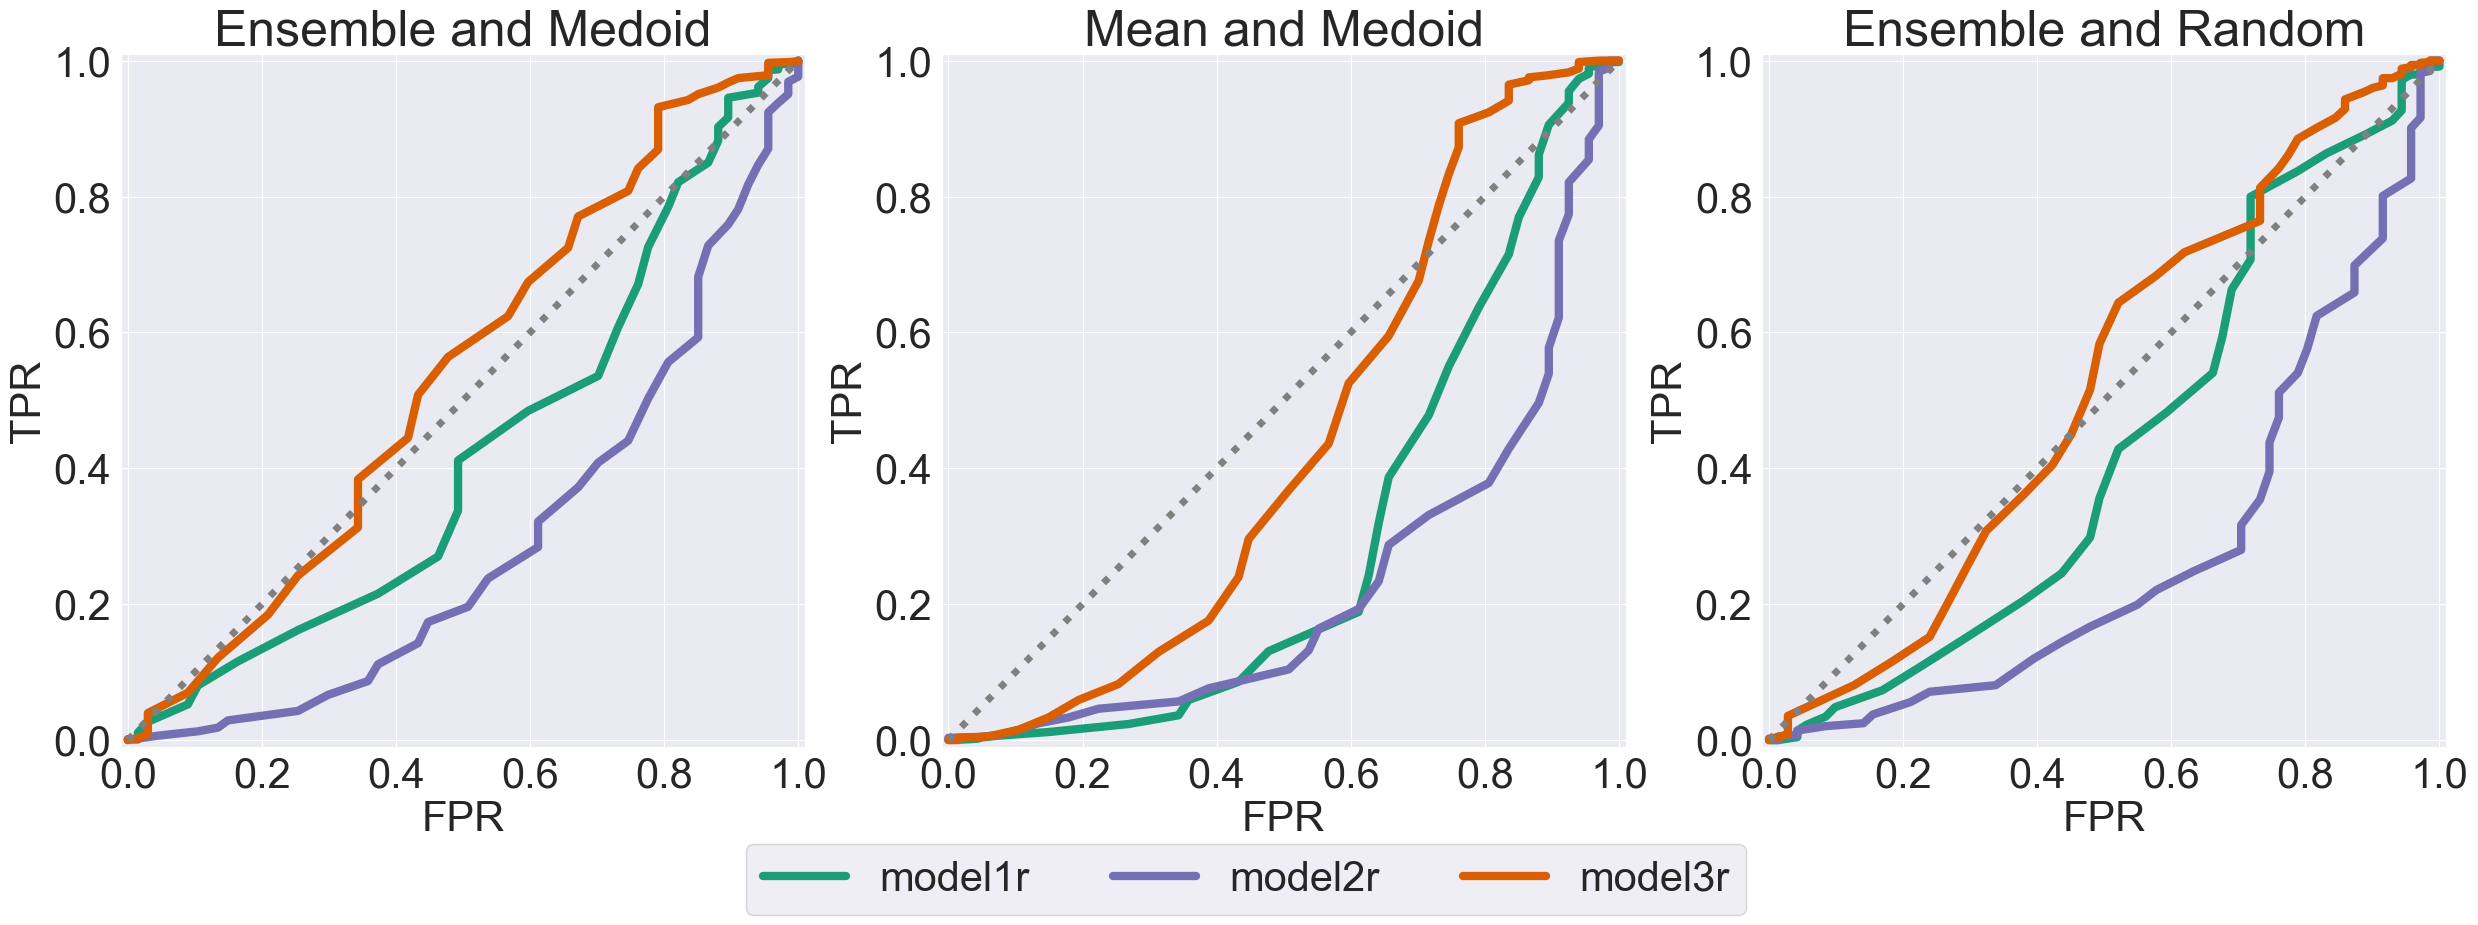

In [54]:
x_ = "FPR"
y_ = "TPR"

fig, ax = plt.subplots(1,3, figsize = (30,9))

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 30

linewidth = 6

model_colors = {f"{model_list[0]}": "#1b9e77",
                f"{model_list[1]}": "#7570b3",
                f"{model_list[2]}": "#d95f02"
                }

dataset_name = "bank"

for i, model_name in enumerate(model_colors.keys()):
    df1 = df_ens
    df2 = df_mean

    de = df1[df1["dataset"]==dataset_name][df1["model"]==model_name]
    dd = df2[df2["dataset"]==dataset_name][df2["model"]==model_name]

    print(de.shape)

    ax[0].plot(de[x_], de[y_], label= f"Model {i+1}", c = model_colors[model_name], linewidth = linewidth, linestyle = "-")
    ax[1].plot(dd[x_], dd[y_],  label= f"Model {i+1}", c = model_colors[model_name], linewidth = linewidth, linestyle = "-")
   

for i, model_name in enumerate(model_colors.keys()):
    df1 = df_ens_random

    de = df1[df1["dataset"]==dataset_name][df1["model"]==model_name]
    ax[2].plot(de[x_], de[y_], label= f"Model {i+1}", c = model_colors[model_name], linewidth = linewidth, linestyle = "-")
    
    
for col in range(3):
    ax[col].set_ylim(-0.01,1.01)
    ax[col].set_xlim(-0.01,1.01)
    ax[col].set_xlabel("FPR")
    ax[col].set_ylabel("TPR")
    ax[col].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax[col].plot(np.linspace(0,1), np.linspace(0,1), ":", c= "gray", linewidth = 5)

ax[0].set_title("Ensemble and Medoid")
ax[1].set_title("Mean and Medoid")
ax[2].set_title("Ensemble and Random")

fig.legend(list(model_colors.keys()), loc='lower center', ncol=3, bbox_to_anchor=(0.5,-0.1), bbox_transform=fig.transFigure)
plt.show()